# Análisis motor 2 y 4

In [1]:
import os
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np           # <--- La que faltaba
import time

In [2]:
ruta = r'N-CMAPSS_DS01-005.h5'

# Asegúrate de que 'ruta' esté definida antes
t = time.process_time()  

#Tardo 24 segundos en cargar el dataset completo, pero es un proceso que solo se hace una vez, así que no es un gran problema.

# Abrir el archivo en modo lectura ('r')
with h5py.File(ruta, 'r') as f:
    print("Contenido del dataset:", list(f.keys()))
    
    # IMPORTANTE: Todas estas líneas deben estar alineadas a la misma altura
    # Development set
    W_dev = np.array(f.get('W_dev'))             # W
    X_s_dev = np.array(f.get('X_s_dev'))         # X_s
    X_v_dev = np.array(f.get('X_v_dev'))         # X_v
    T_dev = np.array(f.get('T_dev'))             # T
    Y_dev = np.array(f.get('Y_dev'))             # RUL  
    A_dev = np.array(f.get('A_dev'))             # Auxiliary

    # Test set
    W_test = np.array(f.get('W_test'))           # W
    X_s_test = np.array(f.get('X_s_test'))       # X_s
    X_v_test = np.array(f.get('X_v_test'))       # X_v
    T_test = np.array(f.get('T_test'))           # T
    Y_test = np.array(f.get('Y_test'))           # RUL  
    A_test = np.array(f.get('A_test'))           # Auxiliary
    
    # Var names (Nombres de las columnas)
    W_var = np.array(f.get('W_var'))
    X_s_var = np.array(f.get('X_s_var'))  
    X_v_var = np.array(f.get('X_v_var')) 
    T_var = np.array(f.get('T_var'))
    A_var = np.array(f.get('A_var'))
    
    # De np.array a lista con encoding para que sean legibles
    W_var = list(np.array(W_var, dtype='U20'))
    X_s_var = list(np.array(X_s_var, dtype='U20'))  
    X_v_var = list(np.array(X_v_var, dtype='U20')) 
    T_var = list(np.array(T_var, dtype='U20'))
    A_var = list(np.array(A_var, dtype='U20'))

# Concatenar fuera del bloque 'with' (Opcional, pero más limpio)
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
T = np.concatenate((T_dev, T_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0) 
A = np.concatenate((A_dev, A_test), axis=0) 
    
print('')
print("Operation time (min): " , (time.process_time()-t)/60)
print('')
print ("W shape: " + str(W.shape))
print ("X_s shape: " + str(X_s.shape))
print ("X_v shape: " + str(X_v.shape))
print ("T shape: " + str(T.shape))
print ("A shape: " + str(A.shape))

Contenido del dataset: ['A_dev', 'A_test', 'A_var', 'T_dev', 'T_test', 'T_var', 'W_dev', 'W_test', 'W_var', 'X_s_dev', 'X_s_test', 'X_s_var', 'X_v_dev', 'X_v_test', 'X_v_var', 'Y_dev', 'Y_test']

Operation time (min):  0.055989583333333336

W shape: (7641868, 4)
X_s shape: (7641868, 14)
X_v shape: (7641868, 14)
T shape: (7641868, 10)
A shape: (7641868, 4)


# Generación de datasets necesarios: 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Combinamos todos los arrays en uno solo antes de crear el DataFrame
# Esto evita el error de inserción de columnas en NumPy 2.0
datos_completos = np.column_stack([X_s, A[:, 0], A[:, 2], Y.flatten()])
nombres_columnas = X_s_var + ['unit', 'flight_phase', 'RUL']

df_estudio2 = pd.DataFrame(datos_completos, columns=nombres_columnas)

# Motor 2:
# 2. Aislar el Motor 2.0 en fase de Crucero (la más estable para ver el fallo)
unidad_id = 2.0
df_motor2 = df_estudio2[(df_estudio2['unit'] == unidad_id) & (df_estudio2['flight_phase'] == 3.0)].copy()
df_motor2 = df_motor2.sort_values('RUL', ascending=False) # El tiempo avanza hacia RUL 0


print("✅ DataFrame creado con éxito. Tamaño:", df_estudio2.shape)
print("✅ DataFrame creado con éxito. Tamaño:", df_motor2.shape)

✅ DataFrame creado con éxito. Tamaño: (7641868, 17)
✅ DataFrame creado con éxito. Tamaño: (1049088, 17)


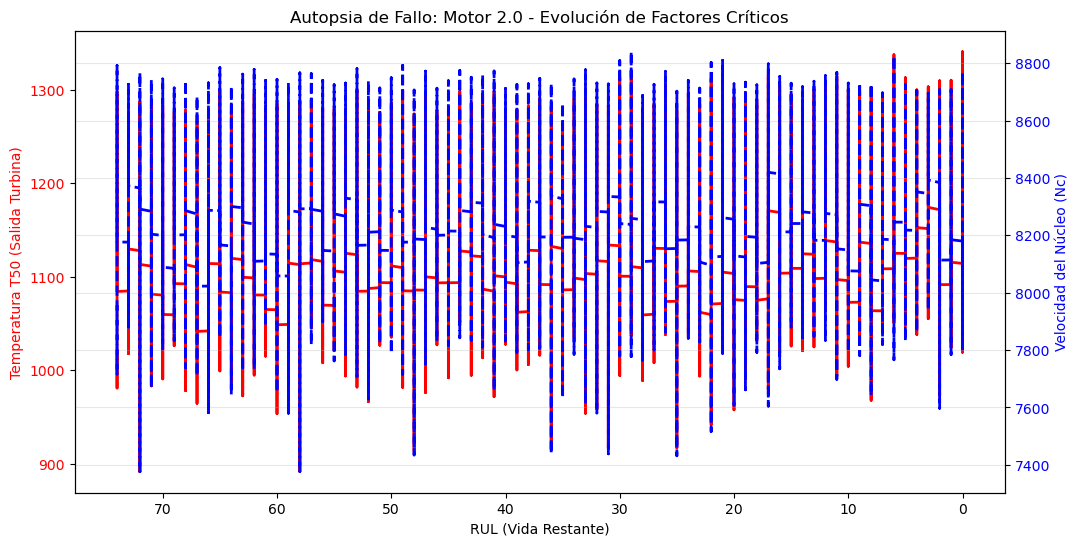

In [4]:

# 2. Aislar el Motor 2.0 en fase de Crucero (la más estable para ver el fallo)
unidad_id = 2.0
df_motor2 = df_estudio2[(df_estudio2['unit'] == unidad_id) & (df_estudio2['flight_phase'] == 3.0)].copy()
df_motor2 = df_motor2.sort_values('RUL', ascending=False) # El tiempo avanza hacia RUL 0

# 3. Calcular la tendencia de los factores influyentes (T50 y Nc)
# Usamos una media móvil para ver la degradación real sin ruido térmico
df_motor2['T50_trend'] = df_motor2['T50'].rolling(window=50).mean()
df_motor2['Nc_trend'] = df_motor2['Nc'].rolling(window=50).mean()

# 4. Graficar la "Firma del Fallo"
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje para Temperatura T50 (Factor negativo: sube al fallar)
ax1.set_xlabel('RUL (Vida Restante)')
ax1.set_ylabel('Temperatura T50 (Salida Turbina)', color='red')
ax1.plot(df_motor2['RUL'], df_motor2['T50_trend'], color='red', linewidth=2, label='T50 (Tendencia)')
ax1.tick_params(axis='y', labelcolor='red')

# Eje para Nc (Velocidad: suele intentar compensar la pérdida de eficiencia)
ax2 = ax1.twinx()
ax2.set_ylabel('Velocidad del Núcleo (Nc)', color='blue')
ax2.plot(df_motor2['RUL'], df_motor2['Nc_trend'], color='blue', linewidth=2, linestyle='--', label='Nc (Tendencia)')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title(f'Autopsia de Fallo: Motor {unidad_id} - Evolución de Factores Críticos')
plt.gca().invert_xaxis() # El fallo está a la derecha (RUL=0)
plt.grid(True, alpha=0.3)
plt.show()

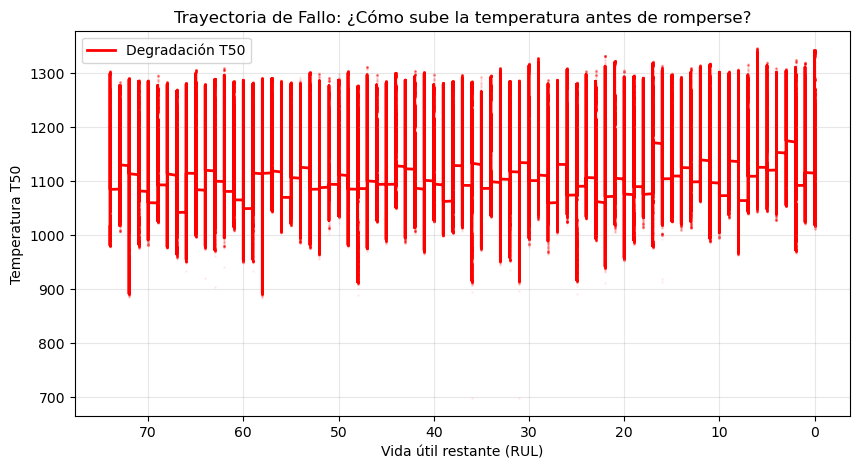

In [5]:
# 3. Aplicamos el suavizado (Media Móvil) para ver la curva real
df_motor2['T50_smooth'] = df_motor2['T50'].rolling(window=50).mean()

# 4. Graficamos la trayectoria de degradación
plt.figure(figsize=(10, 5))
plt.plot(df_motor2['RUL'], df_motor2['T50_smooth'], color='red', linewidth=2, label='Degradación T50')
plt.scatter(df_motor2['RUL'], df_motor2['T50'], color='red', alpha=0.05, s=1)

plt.gca().invert_xaxis() # El fallo (RUL=0) queda a la derecha
plt.title('Trayectoria de Fallo: ¿Cómo sube la temperatura antes de romperse?')
plt.xlabel('Vida útil restante (RUL)')
plt.ylabel('Temperatura T50')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [6]:
# 1. Asegurarnos de que el motor 2 esté ordenado por tiempo (RUL de 100 a 0)
df_motor2 = df_motor2.sort_values('RUL', ascending=False)

# 2. Tomar muestras del inicio (nuevo) y del final (fallo)
n_muestras = 50
estado_nuevo = df_motor2.iloc[:n_muestras][X_s_var].mean()
estado_fallo = df_motor2.iloc[-n_muestras:][X_s_var].mean()

# 3. Calcular la variación porcentual real
variacion_pct = ((estado_fallo - estado_nuevo) / estado_nuevo) * 100

# 4. Mostrar resultados (Cambiado 'unidad_real' por 'unidad_id')
print(f"--- Factores de Influencia Reales (Motor {unidad_id}) ---")
print("¿Cuánto cambió cada sensor justo antes de romperse?")
print(variacion_pct.sort_values(ascending=False))

--- Factores de Influencia Reales (Motor 2.0) ---
¿Cuánto cambió cada sensor justo antes de romperse?
P2      -0.850365
T24     -8.026473
Nc      -8.231929
T50    -10.636527
P50    -10.910901
T30    -14.336901
P21    -15.203151
P15    -15.203151
T48    -19.024269
P24    -23.223095
Nf     -25.340676
P40    -42.291980
Ps30   -42.537332
Wf     -53.061857
dtype: float64


--- Parámetros que más influyen en la variación de T50 (Motor 2.0) ---
T50     1.000000
Wf      0.978533
Ps30    0.967595
P40     0.966458
T24     0.962622
T30     0.931273
Nc      0.917826
P24     0.841114
T48     0.831092
P21     0.752944
P15     0.752944
P50     0.703439
P2      0.590729
Nf      0.510587
Name: T50, dtype: float64


KeyboardInterrupt: 

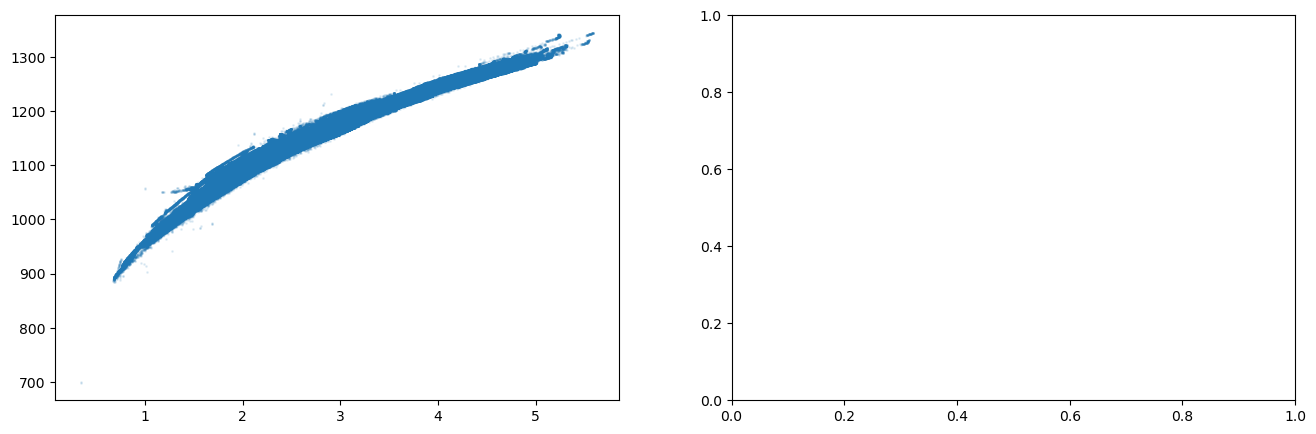

In [7]:
# 1. Calcular la matriz de correlación interna para el Motor 2.0 (Fase Crucero)
# Nos enfocamos solo en la relación de T50 con los demás sensores
corr_T50 = df_motor2[X_s_var].corr()['T50'].sort_values(ascending=False)

print("--- Parámetros que más influyen en la variación de T50 (Motor 2.0) ---")
print(corr_T50)

# 2. Visualización: Relación entre T50 y sus 2 principales aliados
import seaborn as sns

# Tomamos los dos sensores con correlación más fuerte (positiva o negativa)
top_aliados = corr_T50.index[1:3] # El índice 0 es T50 misma

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

for i, sensor in enumerate(top_aliados):
    sns.regplot(data=df_motor2, x=sensor, y='T50', ax=ax[i], 
                scatter_kws={'alpha':0.1, 's':1}, line_kws={'color':'black'})
    ax[i].set_title(f'Relación Física: {sensor} vs T50')
    ax[i].grid(True, alpha=0.3)

plt.suptitle('¿Qué hace variar a la T50 en el Motor 2.0?', fontsize=16)
plt.show()

In [6]:
# Ejemplo para demostrar el fallo en el Motor 2.0
# 1. Calculamos la media de 'buena salud' (primeros 50 ciclos)
media_sana = df_motor2.iloc[:50]['T50'].mean()

# 2. Calculamos la desviación actual
df_motor2['Desviacion_T50'] = df_motor2['T50'] - media_sana

# 3. Demostramos el fallo: Verás que al final la desviación es máxima
print(f"Desviación al fallo: {df_motor2['Desviacion_T50'].iloc[-1]:.2f} unidades")

Desviación al fallo: -141.98 unidades


Quiero demostrar lo que dices que los rendimientos de los componentes bajan y también que se quema más combustible. También quiero demostrar

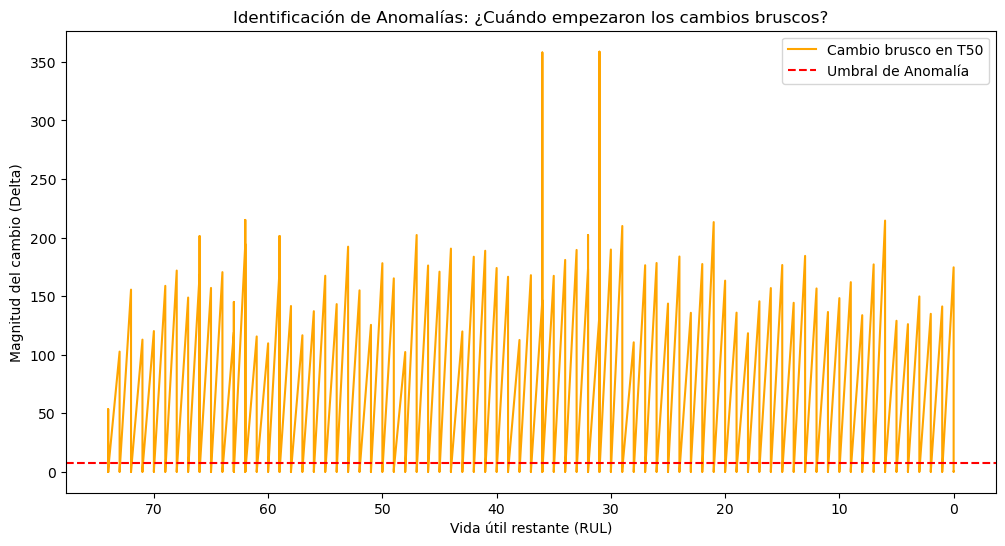

--- Detección de Anomalías Bruscas ---
La primera anomalía brusca en T50 se detectó a un RUL de: 74.0


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcular el gradiente (cambio brusco) para los sensores principales
# El gradiente mide cuánto cambia el valor de un ciclo a otro
df_motor2['T50_diff'] = df_motor2['T50'].diff().abs()
df_motor2['Ps30_diff'] = df_motor2['Ps30'].diff().abs()

# 2. Identificar el umbral de anomalía (3 veces la desviación estándar típica)
umbral_T50 = df_motor2['T50_diff'].mean() + (3 * df_motor2['T50_diff'].std())

# 3. Graficar los cambios bruscos
plt.figure(figsize=(12, 6))

# Visualizamos la "tasa de cambio"
plt.plot(df_motor2['RUL'], df_motor2['T50_diff'], color='orange', label='Cambio brusco en T50')
plt.axhline(y=umbral_T50, color='red', linestyle='--', label='Umbral de Anomalía')

# Invertimos el eje para ver el fallo a la derecha (RUL -> 0)
plt.gca().invert_xaxis()

plt.title('Identificación de Anomalías: ¿Cuándo empezaron los cambios bruscos?')
plt.xlabel('Vida útil restante (RUL)')
plt.ylabel('Magnitud del cambio (Delta)')
plt.legend()
plt.show()

# 4. Identificar quién mostró la primera anomalía significativa
print("--- Detección de Anomalías Bruscas ---")
anomalias = df_motor2[df_motor2['T50_diff'] > umbral_T50]
if not anomalias.empty:
    primer_fallo = anomalias['RUL'].max()
    print(f"La primera anomalía brusca en T50 se detectó a un RUL de: {primer_fallo}")

In [11]:
import pandas as pd
import numpy as np

# 1. Definir la lista de variables a analizar (según tu correlación con T50)
variables_analisis = ['T50', 'Wf', 'Ps30', 'P40', 'T24', 'T30', 'Nc', 'P24', 'T48', 'P15', 'P21', 'P50', 'P2', 'Nf']

# 2. Asegurar que los datos están ordenados por tiempo (RUL de mayor a menor)
df_motor2 = df_motor2.sort_values('RUL', ascending=False)

resultados_anomalias = []

for var in variables_analisis:
    # Calcular el cambio brusco absoluto ciclo a ciclo
    diff = df_motor2[var].diff().abs()
    
    # Establecer umbral: media del cambio + 3 sigmas (desviación estándar)
    # Esto identifica cambios que son estadísticamente imposibles en operación normal
    umbral = diff.mean() + (3 * diff.std())
    
    # Buscar el RUL más alto (el momento más temprano) donde se supera el umbral
    momentos_anomalia = df_motor2.loc[diff > umbral, 'RUL']
    
    if not momentos_anomalia.empty:
        primer_momento = momentos_anomalia.max()
        resultados_anomalias.append({'Variable': var, 'Ciclo_Anomalia_RUL': primer_momento})

# 3. Crear DataFrame de resultados y ordenar
df_resumen_fallos = pd.DataFrame(resultados_anomalias)
df_resumen_fallos = df_resumen_fallos.sort_values('Ciclo_Anomalia_RUL', ascending=False)

print("--- Cronología de Anomalías en Fase Crucero ---")
print("El ciclo con RUL más alto indica quién falló PRIMERO.")
print(df_resumen_fallos.to_string(index=False))

--- Cronología de Anomalías en Fase Crucero ---
El ciclo con RUL más alto indica quién falló PRIMERO.
Variable  Ciclo_Anomalia_RUL
     T50                74.0
      Wf                74.0
    Ps30                74.0
     P40                74.0
     T24                74.0
     T30                74.0
      Nc                74.0
     P24                74.0
     T48                74.0
     P15                74.0
     P21                74.0
     P50                74.0
      P2                74.0
      Nf                74.0


C:\Users\11jav\AppData\Local\Temp\ipykernel_19416\4219819386.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\11jav\miniconda3\envs\notebook\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


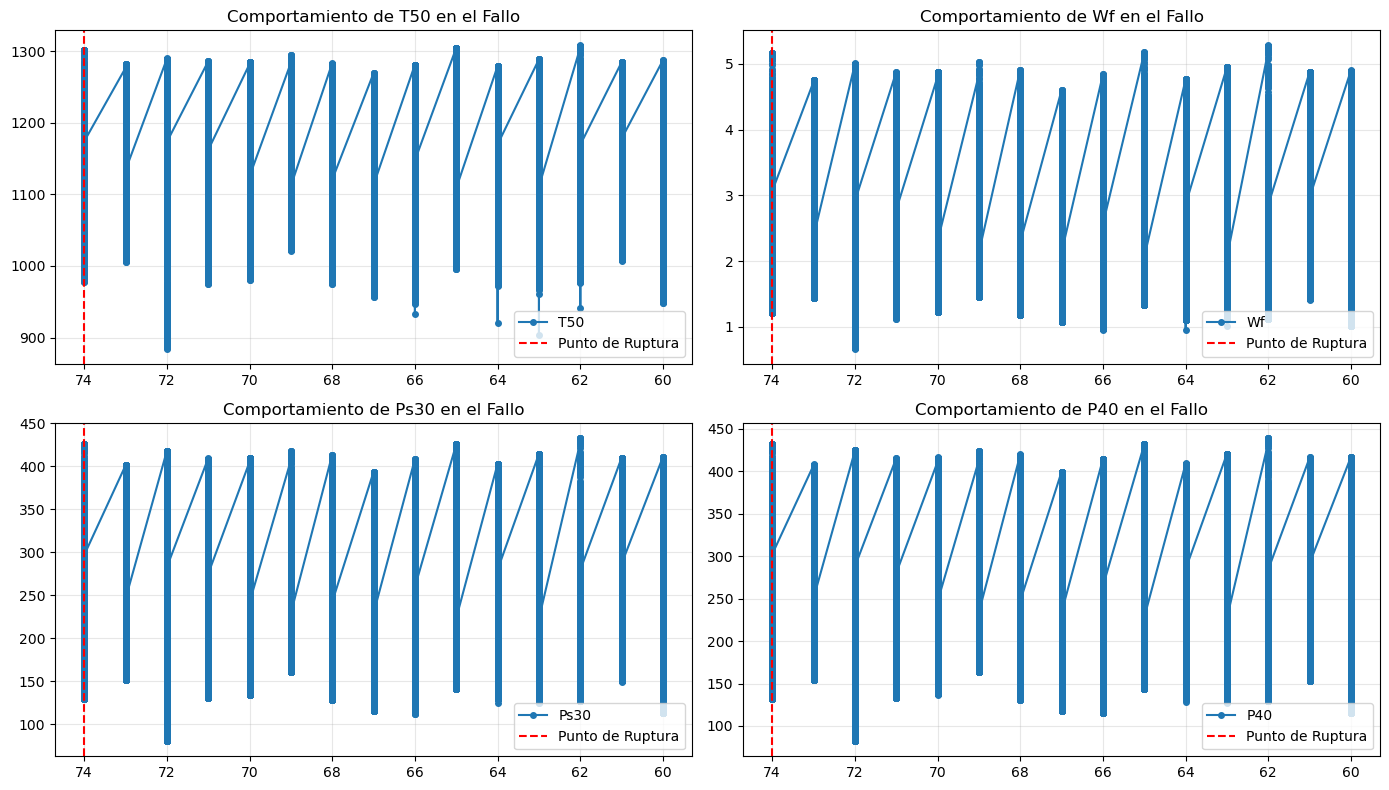

--- Magnitud del salto en el ciclo 74.0 ---


IndexError: index 0 is out of bounds for axis 0 with size 0

In [13]:
import matplotlib.pyplot as plt

# 1. Definir las variables clave que mostraron anomalía simultánea
variables_criticas = ['T50', 'Wf', 'Ps30', 'P40']

# 2. Crear una gráfica comparativa centrada en el momento del fallo (RUL 80 a 60)
plt.figure(figsize=(14, 8))

for i, var in enumerate(variables_criticas):
    plt.subplot(2, 2, i+1)
    # Filtramos una ventana cercana al ciclo 74 para ver el detalle
    ventana_fallo = df_motor2[(df_motor2['RUL'] <= 85) & (df_motor2['RUL'] >= 60)]
    
    plt.plot(ventana_fallo['RUL'], ventana_fallo[var], marker='o', markersize=4, label=var)
    plt.axvline(x=74.0, color='red', linestyle='--', label='Punto de Ruptura')
    
    plt.title(f'Comportamiento de {var} en el Fallo')
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# 3. Cálculo de la magnitud del salto en el ciclo 74
print("--- Magnitud del salto en el ciclo 74.0 ---")
for var in variables_criticas:
    # Calculamos la diferencia porcentual en el punto de anomalía
    valor_anterior = df_motor2.loc[df_motor2['RUL'] == 75.0, var].values[0]
    valor_anomalia = df_motor2.loc[df_motor2['RUL'] == 74.0, var].values[0]
    salto_pct = ((valor_anomalia - valor_anterior) / valor_anterior) * 100
    print(f"{var}: Salto del {salto_pct:.2f}%")

In [12]:
import pandas as pd
import numpy as np

# Variables que presentaron anomalía simultánea en el ciclo 74
variables_lista = ['T50', 'Wf', 'Ps30', 'P40', 'Nc', 'T24', 'T48']

# 1. Función para corroborar la intensidad del fallo
def analizar_impacto_anomalia(df, variables, ciclo_ruptura):
    impactos = []
    
    for var in variables:
        # Valor en el ciclo previo al fallo (estabilidad)
        v_sano = df.loc[df['RUL'] == ciclo_ruptura + 1, var].values[0]
        # Valor en el ciclo del fallo (anomalía detectada)
        v_fallo = df.loc[df['RUL'] == ciclo_ruptura, var].values[0]
        
        # Cambio porcentual: (Fallo - Sano) / Sano
        cambio_pct = ((v_fallo - v_sano) / v_sano) * 100
        impactos.append({'Sensor': var, 'Impacto_Pct': cambio_pct})
    
    return pd.DataFrame(impactos).sort_values('Impacto_Pct', ascending=False)

# 2. Ejecución de la corroboración
df_impacto = analizar_impacto_anomalia(df_motor2, variables_lista, 74.0)

print("--- Corroboración de Intensidad de Anomalía ---")
print("El sensor con el Impacto_Pct más extremo identifica la causa raíz.")
print(df_impacto.to_string(index=False))

IndexError: index 0 is out of bounds for axis 0 with size 0